# 1. ¿Qué es la Teoría de Grafos?

**La teoría de grafos** es una rama de las matemáticas y la informática que estudia estructuras formadas por:
*   Nodos (vértices) → entidades
*   Aristas (edges) → relaciones entre nodos

Ejemplos reales:
* Redes sociales (personas ↔ amistades)
* Mapas (ciudades ↔ rutas)
* Internet (servidores ↔ conexiones)
* Planificación y logística




# 2. Librerías

In [ ]:
# Esta instalación sólo se debe hacer una vez

!pip install networkx matplotlib

In [ ]:
# Carga de las librerías a utilizar

import networkx as nx
import matplotlib.pyplot as plt

# 3. Grafo base
## Red tipo “ciudades conectadas”

In [ ]:
# Creamos un objeto llamado G que es un grafo
G = nx.Graph()

# Definimos los nodos que va a contener
nodos = [
    "A","B","C","D","E",
    "F","G","H","I","J"
]

# Agregamos los nodos al grafo
G.add_nodes_from(nodos)

# Determinamos las conexiones entre nodos
aristas = [
    ("A","B"), ("A","C"), ("B","D"), ("C","D"),
    ("D","E"), ("E","F"), ("F","G"), ("E","G"),
    ("G","H"), ("H","I"), ("I","J"),
    ("C","F"), ("B","G"), ("E","I")
]

# Se agregan las conexiones al grafo
G.add_edges_from(aristas)

### Visualización - Grafo no dirigido

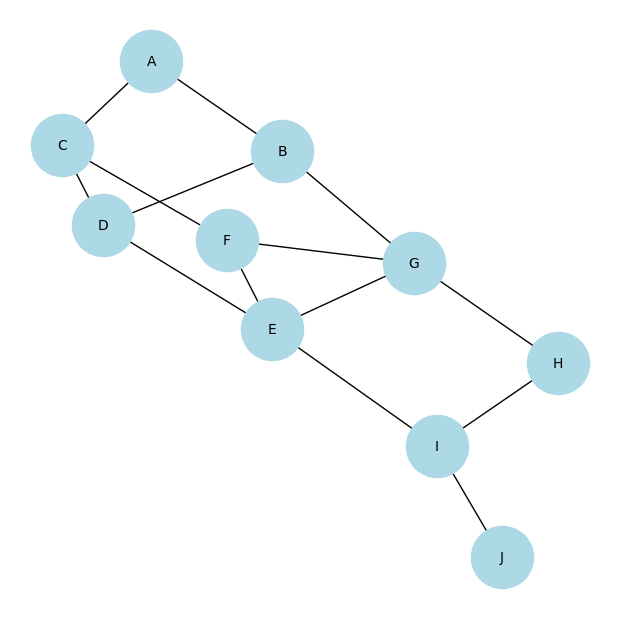

In [ ]:
# Se define las características de la figura a dibujar
plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=2000,
    font_size=10,
)

# Dibujamos el grafo
plt.show()

## Creando un Grafo Dirigido

In [ ]:
# Creamos un objeto llamado G1 que es un grafo
G1 = nx.DiGraph() # DiGraph define un grafo definido

# Definimos los nodos que va a contener
nodos = [
    "a","b","c"
]

# Agregamos los nodos al grafo
G1.add_nodes_from(nodos)

# Determinamos las conexiones entre nodos
aristas = [
    ("a", "b"), ("b", "a"), ("c", "a"), ("c", "c")
]

# Se agregan las conexiones al grafo
G1.add_edges_from(aristas)

### Visualización Grafo dirigido

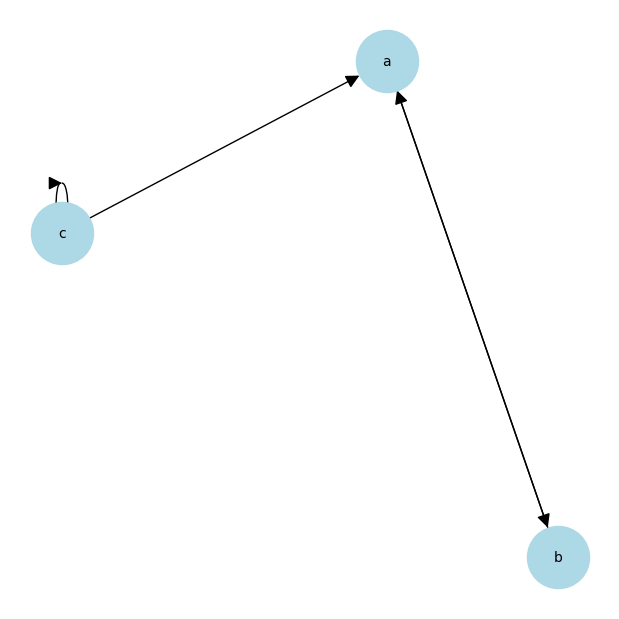

In [ ]:
# Se define las características de la figura a dibujar
plt.figure(figsize=(6,6))
pos = nx.spring_layout(G1, seed=42)

nx.draw(
    G1, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=2000,
    font_size=10,
    arrowsize=20
)

# Dibujamos el grafo
plt.show()

# 4. Propiedades estructurales
## Grado de nodos

In [ ]:
# Vemos los grados de los nodos de nuestro grafo G
grados = dict(G.degree())
print(grados)

grados = dict(G1.degree())
print(grados)

#grados = dict(DG.degree())
#print(grados)

{'A': 2, 'B': 3, 'C': 3, 'D': 3, 'E': 4, 'F': 3, 'G': 4, 'H': 2, 'I': 3, 'J': 1}
{'a': 3, 'b': 2, 'c': 3}


##  Interpretación
* nodos con alto grado → hubs
* vulnerabilidad estructural
* analogía: aeropuertos principales

Con esto podemos responder:
* ¿Qué nodo es un hub?
* ¿Cuáles son nodos terminales?

# 5. Caminos y distancias
## Camino más corto

In [ ]:
nx.shortest_path(G, "A", "J")

['A', 'B', 'G', 'H', 'I', 'J']

## Distancia

In [ ]:
nx.shortest_path_length(G, "A", "J")

5

## Discusión:

* ¿qué nodos aparecen frecuentemente en caminos?
* ¿hay “cuellos de botella”?




# 6. Grafo ponderado

In [ ]:
G_w = nx.Graph()

G_w.add_weighted_edges_from([
    ("A","B",4), ("A","C",2), ("B","D",5),
    ("C","D",1), ("D","E",3), ("E","F",2),
    ("F","G",4), ("G","H",1), ("H","I",6),
    ("I","J",3), ("C","F",7), ("B","G",8),
    ("E","I",5), ("E","G",3),
])

## Camino mínimo

In [ ]:
# Repetimos el comando de arriba para comparar

print(nx.shortest_path(G_w, "A", "J") ,"\n" , nx.shortest_path(G_w, "A", "J", weight="weight"))


['A', 'B', 'G', 'H', 'I', 'J'] 
 ['A', 'C', 'D', 'E', 'I', 'J']


In [ ]:
nx.shortest_path_length(G_w, "A", "J", weight="weight")

14

## Interpretación:

* trade-off entre rutas directas vs costo
* equivalente a problemas de logística

In [ ]:
P = nx.DiGraph()

P.add_edges_from([
    ("S0","S1"), ("S0","S2"),
    ("S1","S3"), ("S2","S3"),
    ("S3","S4"), ("S4","S5"),
    ("S5","S6"), ("S6","S7"),
    ("S7","S8"), ("S8","Goal"),
    ("S2","S6"), ("S1","S5")
])

## 7. Resolver planning

In [ ]:
nx.shortest_path(P, "S0", "Goal")

['S0', 'S2', 'S6', 'S7', 'S8', 'Goal']

## Esto modela:

* estados → nodos
* acciones → aristas
* solución → camino



# 8. Centralidad (estructura profunda)

In [ ]:
nx.degree_centrality(G)

{'A': 0.2222222222222222,
 'B': 0.3333333333333333,
 'C': 0.3333333333333333,
 'D': 0.3333333333333333,
 'E': 0.4444444444444444,
 'F': 0.3333333333333333,
 'G': 0.4444444444444444,
 'H': 0.2222222222222222,
 'I': 0.3333333333333333,
 'J': 0.1111111111111111}

In [ ]:
nx.betweenness_centrality(G)

{'A': 0.013888888888888888,
 'B': 0.13981481481481478,
 'C': 0.09166666666666667,
 'D': 0.12407407407407407,
 'E': 0.32222222222222224,
 'F': 0.11527777777777778,
 'G': 0.2513888888888889,
 'H': 0.0574074074074074,
 'I': 0.24537037037037032,
 'J': 0.0}

## Interpretación:

nodos con alta betweenness:
* controlan flujo
* puntos críticos del sistema

# 9. Componentes conexas

In [ ]:
list(nx.connected_components(G))

[{'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'}]

## Modificar el grafo (eliminar aristas) y observar:

* fragmentación de red
* resiliencia

# 10. Generación de grafos realistas
## Red tipo escala libre (Barabási–Albert)

In [ ]:
BA = nx.barabasi_albert_graph(10, 2)

nx.draw(BA, with_labels=True)
plt.show()